## Problem Set 3 for D400

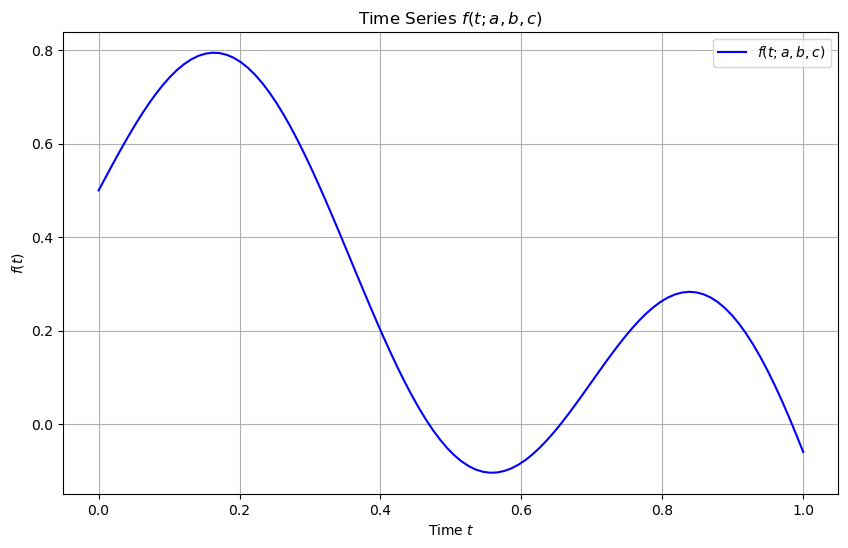

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

# Example usage
# Define parameters
a = 0.1
b = -0.13
c = 9


# Define time range
t = np.linspace(0, 1, 100)  # time from 0 to 1 with 100 points

# Calculate f(t) for these parameters
f_values = f(t, a, b, c)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()

Or with parameters...

In [ ]:
from ipywidgets import interactive
import ipywidgets as widgets


def plot_with_parameters(a, b, c):
    # Define time range
    t = np.linspace(0, 1, 100)

    # Calculate f(t) for these parameters
    f_values = f(t, a, b, c)

    # Plot the function
    plt.figure(figsize=(10, 6))
    plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
    plt.xlabel('Time $t$')
    plt.ylabel(r'$f(t)$')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.legend()
    plt.grid(True)
    plt.show()

# Create interactive widget
interactive_plot = interactive(
    plot_with_parameters,
    a=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.1),
    b=widgets.FloatSlider(min=-0.5, max=0.5, step=0.01, value=-0.13),
    c=widgets.FloatSlider(min=5, max=10, step=0.1, value=9)
)

display(interactive_plot)

interactive(children=(FloatSlider(value=0.1, description='a', max=1.0, step=0.01), FloatSlider(value=-0.13, de…

Question 1
Consider all parameter values (except t) are fixed and create an interpolator with respect to time t.

In [4]:
t = np.linspace(0, 1, 100)

from scipy.interpolate import interp1d

# Define time points and corresponding function values for a specific `a`
x = t  # Time points, assumed to be defined previously

y = f_values  # Function values at each time point `t` for a fixed `a`

# Create the interpolator function with respect to time `t`
F_interp_t = interp1d(x, y, kind='linear', fill_value="extrapolate")

Question 2
Evaluate the interpolator on a much finer grid than the original grid.

In [5]:
# Now you can use `F_interp_t` to interpolate the function at any time `t_new`
# Example:
t_new = np.linspace(0, 1, 1001) # An example time point within the range
f_value_at_t_new = F_interp_t(t_new)  # Interpolated value at t_new

Question 3
Show the results of question 2 in a plot, showing both the exact function and the predictions of the interpolator.

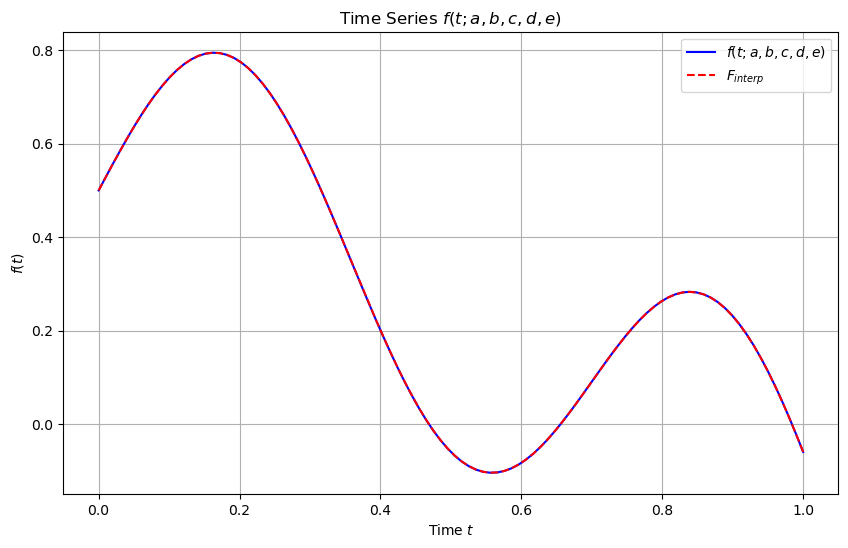

In [6]:
# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c, d, e)$', color='blue')
plt.plot(t_new, f_value_at_t_new, label=r'$F_{interp}$', color='red',ls='--')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c, d, e)$')
plt.legend()
plt.grid(True)
plt.show()

Question 4
Show the ratio of the interpolated values to true values accross the fine time grid.

What do you observe? Does it make sense?

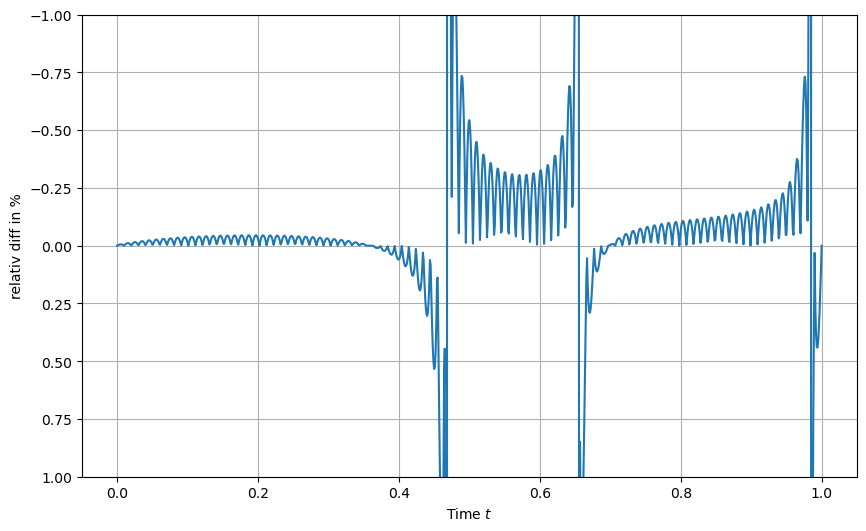

In [7]:
# Plot the function
plt.figure(figsize=(10, 6))

r = 100*(f_value_at_t_new-f(t_new, a, b, c))/f(t_new, a, b, c)
plt.plot(t_new, r)
plt.xlabel('Time $t$')
plt.ylabel(r'relativ diff in %')

plt.ylim(1,-1)
plt.grid(True)
plt.show()

The results are often very close together, and oscillate around zero, particularly around [0.0,0,4] and [0.5,0.6] for example. But, it diverges at particular points and in the neighbour of points where there are stationary points**

Question 5
Consider now all paramaters fixed except a
 (and 
t).

We assume the parameter a
 can take values between 0 and 1.

Generate 10 samples of f
 (i.e., 10 time series) corresponding to linearly spaced values of 
 spanning the interval.

Store them in a pandas DataFrame and plot them with the plot method of the DataFrame.

In [8]:
import pandas as pd


# Generate 10 linearly spaced values of `a` from 0. to 1.0
a_values = np.linspace(0., 1.0, 10)

# Generate samples and store them in a DataFrame with labels from 1 to 10
f_samples_labeled = {str(i+1): f(t, a, b, c) for i, a in enumerate(a_values)}
f_samples_labeled_df = pd.DataFrame(f_samples_labeled, index=t)

In [9]:
f_samples_labeled_df

,1,2,3,4,5,6,7,8,9,10
0.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
0.010101,0.499898,0.530199,0.542750,0.552381,0.560500,0.567653,0.574120,0.580067,0.585602,0.590801
0.020202,0.499592,0.560023,0.585055,0.604262,0.620454,0.634720,0.647618,0.659478,0.670517,0.680886
0.030303,0.499082,0.589223,0.626560,0.655210,0.679363,0.700643,0.719881,0.737572,0.754038,0.769504
0.040404,0.498368,0.617551,0.666918,0.704799,0.736734,0.764869,0.790305,0.813696,0.835468,0.855917
...,...,...,...,...,...,...,...,...,...,...
0.959596,-0.170695,0.097127,0.208063,0.293187,0.364950,0.428174,0.485333,0.537896,0.586821,0.632772
0.969697,-0.180154,0.062714,0.163313,0.240505,0.305581,0.362914,0.414747,0.462413,0.506779,0.548448
0.979798,-0.189539,0.026299,0.115702,0.184303,0.242137,0.293089,0.339154,0.381515,0.420943,0.457975
0.989899,-0.198847,-0.011895,0.065544,0.124964,0.175058,0.219191,0.259091,0.295782,0.329934,0.362010


<Axes: >

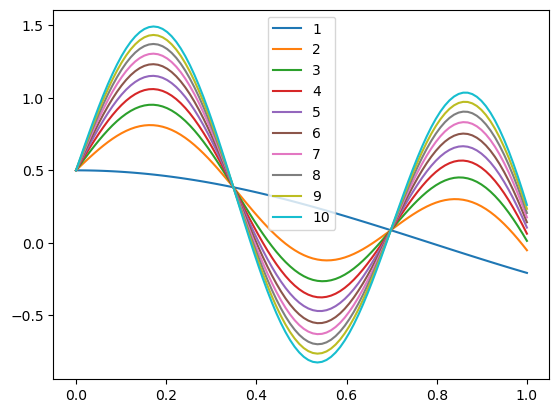

In [10]:
f_samples_labeled_df.plot(legend=True)

Question 6
Create an interpolator that interpolates over a
 (same range as previous question) and returns the full time series (i.e., values of f
 for all time points) over the original time grid, i.e., t
.

`t = np.linspace(0, 1, 100)`
Plot the result for a=0.125 
, like in question 3.

Plot the ratio, like in question 4.

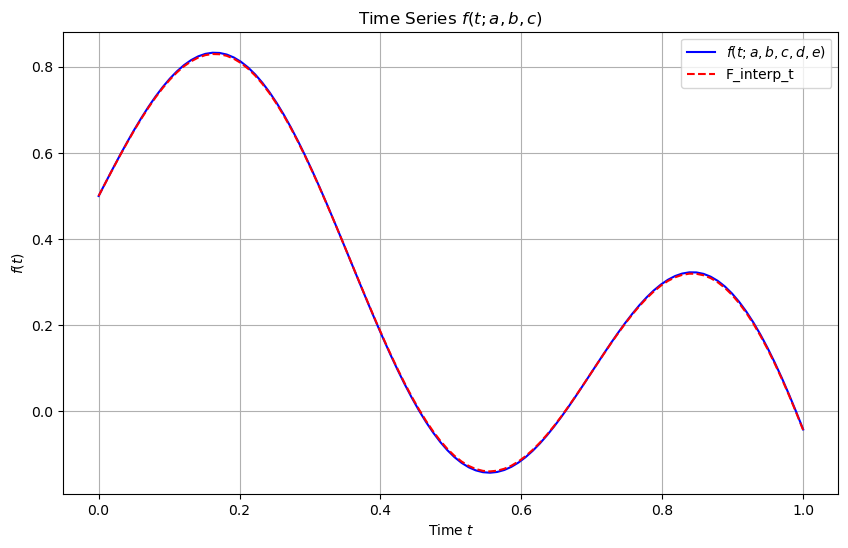

In [11]:
from scipy.interpolate import RegularGridInterpolator

# Convert the DataFrame to a 2D NumPy array with shape (len(t), len(a_values))
f_values_matrix = f_samples_labeled_df.values  # Shape: (100, 10) in this example

# Create an interpolator across `a` and `t`
interpolator = RegularGridInterpolator((t, a_values), f_values_matrix, method="linear", bounds_error=False, fill_value=None)

# Define a function that interpolates over a new `a` value
def interpolate_f_over_a(new_a):
    # Create a mesh of (time, new_a) points
    query_points = np.array([(time, new_a) for time in t])

    # Interpolate at all time points for the given new `a`
    return interpolator(query_points)
ap = 0.125
# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f(t, ap, b, c), label=r'$f(t; a, b, c, d, e)$', color='blue')
plt.plot(t, interpolate_f_over_a(ap), label=r'F_interp_t', color='red',ls='--')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()


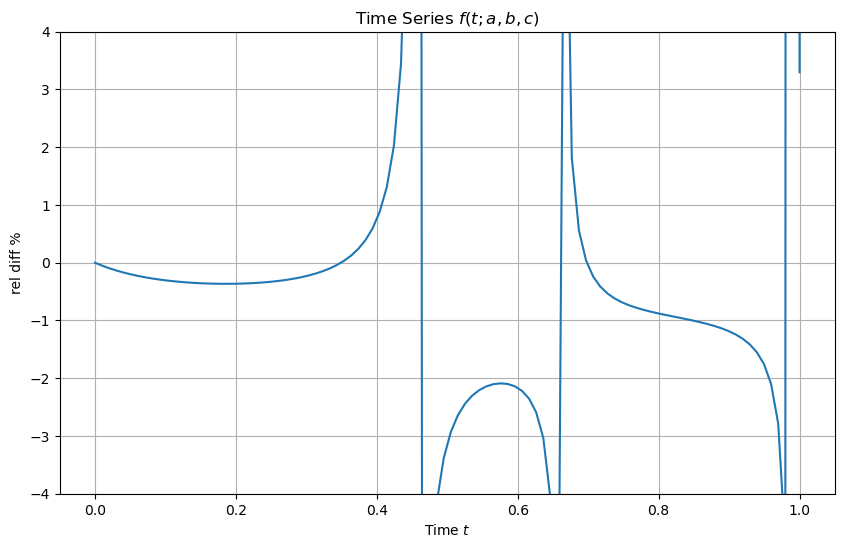

In [12]:
# Plot the function
plt.figure(figsize=(10, 6))
r = 100*(interpolate_f_over_a(ap)/f(t, ap, b, c) - 1 )
plt.plot(t,r)
plt.xlabel('Time $t$')
plt.ylabel(r'rel diff %')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.grid(True)
plt.ylim(-4.,4.)
plt.show()

Less accurate largely but similar differences exhibited - doesn't oscillate.

Question 7
Use widgets from ipywidgets to create a sliding scale of a values.

In this question, you should plot the ratio between the interpolated values and the true values of the function evaluated at the original time grid t.

In [ ]:
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

# Define the slider function to update the plot
def plot_interpolated_relative_difference(ap):
    # Calculate the relative difference
    r = 100 * (interpolate_f_over_a(ap) / f(t, ap, b, c) - 1.)

    # Plot the relative difference
    plt.figure(figsize=(10, 6))
    plt.plot(t, r)
    plt.xlabel('Time $t$')
    plt.ylabel(r'Relative Difference %')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.ylim(-10,10)
    plt.grid(True)
    plt.show()

# Define the slider for `ap`
ap_slider = FloatSlider(value=0.145, min=0., max=1.0, step=0.001, description='ap')

# Use `interact` to create the interactive plot
interact(plot_interpolated_relative_difference, ap=ap_slider)

interactive(children=(FloatSlider(value=0.145, description='ap', max=1.0, step=0.001), Output()), _dom_classes…

<function __main__.plot_interpolated_relative_difference(ap)>

At 1 and 0, differences become smoothed at 0. 

Question 8
From your results of Question 7, what do you observe? Does it make sense?

Once we start linearly interpolating with respect to another variable, we get less accurate results and, so, the magnitude of the relative difference is larger.

Question 9
We will now consider both a
 and b
 as interpolation parameters.

Our interpolator should therefore interpolate accross both a
 and b
 ranges.

Generate 10^2
 parameter value pairs (a,b) 
 in the range 0<a<1
 and -0.5<b<0.5
 using latin hyper cube sampling.

You should use pyDOE to generate the Latin Hyper Cube samples.

You may need to pip install pyDOE to get this package, first.

Show the 
 and 
 samples as a 2D scatter plot.

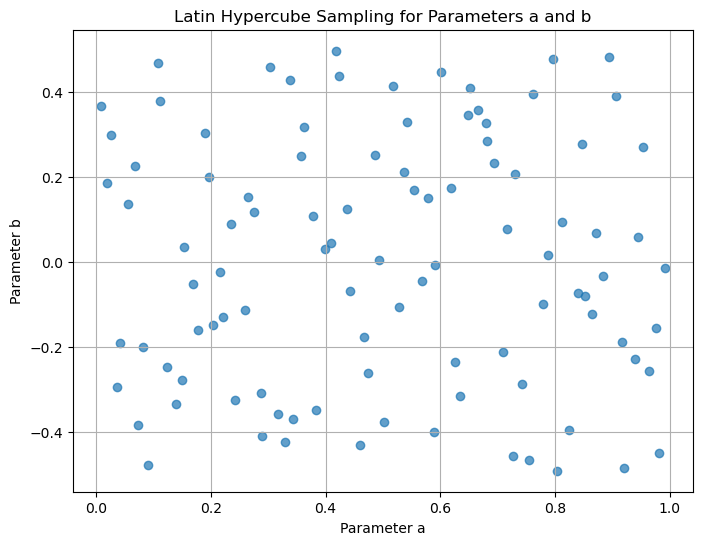

In [14]:
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from pyDOE import lhs  # For Latin Hypercube Sampling

# Define the ranges for `a`, `b`, and `t`
t = np.linspace(0, 1, 100)  # Time range with 100 points
a_range = (0., 1.0)
b_range = (-0.5, 0.5)

# Generate Latin Hypercube samples for `a` and `b`
n_samples = 100  # Define the number of samples for each parameter
lhs_samples = lhs(2, samples=n_samples)  # Latin Hypercube sampling in 2D



# Scale the samples to the range of `a` and `b`
a_values = a_range[0] + lhs_samples[:, 0] * (a_range[1] - a_range[0])
b_values = b_range[0] + lhs_samples[:, 1] * (b_range[1] - b_range[0])
# Plot the Latin Hypercube samples as a 2D scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(a_values, b_values, alpha=0.7)
plt.xlabel("Parameter a")
plt.ylabel("Parameter b")
plt.title("Latin Hypercube Sampling for Parameters a and b")
plt.grid(True)
plt.show()

Question 10
For comparison, on the same plot, add a uniformly sampled realization of 10^2
 a
 and b
 values.

Can you distinguish by eye?

As an extension question, think of how you would proceed if you needed to prove that these samples come from different generative processes (uniform or Latin Hyper Cube).

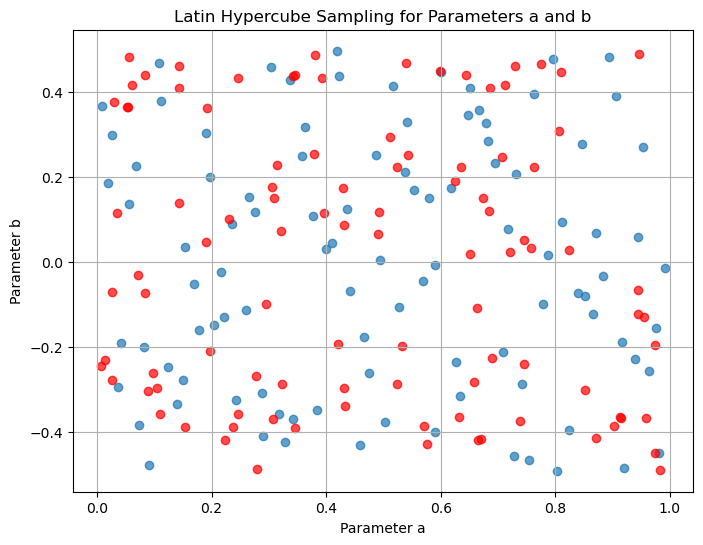

In [15]:
# Generate uniformly sampled values for `a` and `b`
ua_values = np.random.uniform(a_range[0], a_range[1], n_samples)
ub_values = np.random.uniform(b_range[0], b_range[1], n_samples)

# Plot the Latin Hypercube samples as a 2D scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(a_values, b_values, alpha=0.7)
plt.scatter(ua_values, ub_values, alpha=0.7,c='r')
plt.xlabel("Parameter a")
plt.ylabel("Parameter b")
plt.title("Latin Hypercube Sampling for Parameters a and b")
plt.grid(True)
plt.show()

Question 11
Create the interpolator over the parameter space (a,b)
, interpolating over samples of the function evaluated at the original time grid t
.

As you will realise, we are dealing with an irregular grid and need the griddata method (doc).

In [16]:
t = np.linspace(0, 1, 100)  # Time range with 100 points, always fixed

from scipy.interpolate import griddata
# Generate function samples for each (a, b) pair over time `t`
# Create lists to hold points and values for interpolation
points = []  # Will store (t, a, b) tuples
values = []  # Will store corresponding f(t, a, b, c) values

for a, b in zip(a_values, b_values):
    for time in t:
        points.append((time, a, b))
        values.append(f(time, a, b, c))  # Replace `f` with your actual function definition

# Convert lists to NumPy arrays for griddata use
points = np.array(points)  # Shape: (len(t) * n_samples, 3)
values = np.array(values)  # Shape: (len(t) * n_samples,)

# Define a function to interpolate over new values of `a` and `b` using griddata
def interpolate_f_over_a_b(tgrid, new_a, new_b):
    # Create an array of (time, new_a, new_b) points to interpolate
    query_points = np.array([(time, new_a, new_b) for time in tgrid])

    # Use griddata to interpolate the function at the given points
    interpolated_values = griddata(points, values, query_points, method='linear')
    return interpolated_values

Question 12
Show results with a sliding scale plot for a
 and b
.

On a different sliding bar plot, show the ratio between the interpolated values and the true values of the function evaluated at the original time grid t
.

What do you observe?

Does it make sense?

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

tn = np.linspace(0, 1, 100)

# Define the interpolator function for dynamic plotting
def plot_with_interpolated_values(ap, bp):
    # Original function values for given `a` and `b`
    original_values = f(tn, ap, bp, c)  # Replace `f` with your actual function definition

    # Interpolated values for the given `a` and `b`
    # interpolated_values = interpolator([(time, ap, bp) for time in tn])
    interpolated_values = interpolate_f_over_a_b(tn, ap, bp)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(tn, original_values, label=r'$f(t; a, b)$', color='blue',ls='None',marker='o')
    plt.plot(tn, interpolated_values, label=r'$F_{interp}(t)$', color='red', linestyle='None',marker='o')
    plt.xlabel('Time $t$')
    plt.ylabel(r'$f(t)$')
    plt.title(r'Time Series $f(t; a, b)$')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define sliders for `a` and `b`
a_slider = FloatSlider(value=0.125, min=0.0, max=1.0, step=0.01, description='a')
b_slider = FloatSlider(value=0.0, min=-0.5, max=0.5, step=0.01, description='b')

# Use `interact` to create the interactive plot
interact(plot_with_interpolated_values, ap=a_slider, bp=b_slider)

interactive(children=(FloatSlider(value=0.125, description='a', max=1.0, step=0.01), FloatSlider(value=0.0, de…

<function __main__.plot_with_interpolated_values(ap, bp)>